# From picks to a catalog with GaMMA

Notebook 05 produced a pile of picks: a phase name, a time, and the station
it came from. Notebook 03 produced a much bigger pile from the fibre. A pile
of picks is not a catalog. Turning one into the other means deciding **which
picks belong to the same earthquake**, and then where and when that
earthquake was — association and location, in one step.

[GaMMA](https://github.com/AI4EPS/GaMMA) does that by treating the picks as a
Gaussian mixture in which each component is an earthquake, and the travel
time from a hypocentre is the mean. It is a good fit for DAS precisely
because it does not care how many "stations" there are: a channel is a point
that recorded a phase at a time, exactly like a seismometer. So the cable and
the network go into the same association, together, in one run.

```{note}
The install is `pip install git+https://github.com/AI4EPS/GaMMA.git`, and
mind the name: the distribution is called `gmma` but you `import gamma`. The
package on PyPI called `GaMMA` is something else entirely.
```

In [1]:
import numpy as np
import pandas as pd
import pyproj
from obspy import read_inventory

import xdas as xd
from gamma.utils import association

## The two tables GaMMA wants

A **stations** table, positioned in a local Cartesian frame in kilometres,
and a **picks** table keyed by the same station ids. Everything that recorded
something — six seismometers and a few hundred metres-apart fibre channels —
ends up in those same two tables.

In [2]:
picks = pd.read_csv("outputs/station_picks.csv", parse_dates=["time"])
das = pd.read_csv("outputs/picks.csv", parse_dates=["time"])
inventory = read_inventory("data/stations/stations.xml")

rows = [
    (f"{net.code}.{sta.code}", sta.latitude, sta.longitude, sta.elevation)
    for net in inventory
    for sta in net
]
stations = pd.DataFrame(
    rows, columns=["id", "latitude", "longitude", "elevation"]
).drop_duplicates("id")

An azimuthal-equidistant projection centred on the network turns degrees
into kilometres, which is what the travel-time calculation needs:

In [3]:
proj = pyproj.Proj(
    proj="aeqd",
    lat_0=stations["latitude"].mean(),
    lon_0=stations["longitude"].mean(),
    units="km",
)
stations["x(km)"], stations["y(km)"] = proj(
    stations["longitude"].values, stations["latitude"].values
)
stations["z(km)"] = -stations["elevation"] / 1000.0
stations = stations[stations["id"].isin(set("C1." + picks["station"]))]
stations

,id,latitude,longitude,elevation,x(km),y(km),z(km)
9,C1.CO01,-29.97730,-70.09390,2157.0,98.807396,89.672232,-2.157
10,C1.CO02,-31.20370,-71.00030,1190.0,11.188702,-45.847080,-1.190
11,C1.CO03,-30.83890,-70.68910,1003.0,41.001996,-5.474415,-1.003
12,C1.CO04,-32.04330,-70.97470,2401.0,13.507541,-138.944982,-2.401
13,C1.CO05,-29.91864,-71.23841,101.0,-11.656478,96.616871,-0.101
18,C1.VA06,-32.56117,-71.29765,80.0,-16.902025,-196.377769,-0.080


### Every picked channel is a station too

The fibre needs the same three columns, which means knowing where each
channel physically is. That information already travelled here: it was
attached during consolidation (notebook 01) from the real cable geometry.
Pull it off `outputs/singlecable.nc` and interpolate it onto whichever
channels the picker actually fired on:

In [4]:
cable = xd.open("outputs/singlecable.nc")

channels = np.sort(das["distance"].unique())
latitude = np.interp(
    channels, cable["distance"].values, cable["latitude"].values, left=np.nan, right=np.nan
)
longitude = np.interp(
    channels, cable["distance"].values, cable["longitude"].values, left=np.nan, right=np.nan
)

das_stations = pd.DataFrame(
    {"id": [f"DAS.{d:.0f}" for d in channels], "latitude": latitude, "longitude": longitude, "elevation": 0.0}
).dropna(subset=["latitude", "longitude"])
das_stations["x(km)"], das_stations["y(km)"] = proj(
    das_stations["longitude"].values, das_stations["latitude"].values
)
das_stations["z(km)"] = 0.0  # the fiber sits at the surface

print(f"{len(das_stations)} of {len(channels)} picked channels fall on the surveyed 102 km of cable")

173 of 204 picked channels fall on the surveyed 102 km of cable


The channels past 102 km, where the cable was never surveyed, drop out here:
a coordinate is only as good as the survey behind it, and a pick without one
cannot be associated.

## The picks table

Four columns under GaMMA's own names — the station `id`, the `timestamp`,
the phase `type` in lower case, and the model's confidence as `prob` — for
the network and for the fibre alike:

In [5]:
gamma_picks = pd.DataFrame(
    {
        "id": picks["network"] + "." + picks["station"],
        "timestamp": picks["time"],
        "type": picks["phase"].str.lower(),
        "prob": picks["value"],
    }
)

das_gamma_picks = pd.DataFrame(
    {
        "id": das["distance"].map(lambda d: f"DAS.{d:.0f}"),
        "timestamp": das["time"],
        "type": das["phase"].str.lower(),
        "prob": das["value"],
    }
)
das_gamma_picks = das_gamma_picks[das_gamma_picks["id"].isin(das_stations["id"])]
gamma_picks

,id,timestamp,type,prob
0,C1.CO01,2023-11-03 12:27:14.100000,p,0.698469
1,C1.CO01,2023-11-03 12:27:30.820000,s,0.780952
2,C1.CO02,2023-11-03 12:27:14.500000,p,0.715876
3,C1.CO02,2023-11-03 12:27:33.460000,s,0.420162
4,C1.CO03,2023-11-03 12:27:11.700000,p,0.911087
5,C1.CO03,2023-11-03 12:27:27.840000,s,0.536183
6,C1.CO04,2023-11-03 12:27:27.129998,p,0.482439
7,C1.CO04,2023-11-03 12:27:53.549998,s,0.363163
8,C1.CO05,2023-11-03 12:26:57.420000,p,0.967788
9,C1.CO05,2023-11-03 12:27:03.020000,s,0.860738


### Thinning the fibre

The cable brings thirty times more picks than the network, and neighbouring
channels a few hundred metres apart see very nearly the same arrival: the
picks are hugely redundant. GaMMA's cost grows with their number — a real
deployment has tens of thousands of channels, not a hundred and seventy —
so hand the association a **random subsample** and keep the rest for the
figures. A third is plenty here; it locates the same earthquake as the full
set, to within a kilometre of depth, in a third of the time.

In [6]:
sample = das_gamma_picks.sample(frac=1 / 3, random_state=42).sort_index()
held_out = das_gamma_picks.drop(sample.index)

combined_stations = pd.concat([stations, das_stations], ignore_index=True)
combined_picks = pd.concat([gamma_picks, sample], ignore_index=True)

print(
    f"{len(gamma_picks)} station picks + {len(sample)} of {len(das_gamma_picks)} fibre picks "
    f"= {len(combined_picks)} picks over {len(combined_stations)} positions"
)

12 station picks + 121 of 362 fibre picks = 133 picks over 179 positions


## Configuring the association

The search volume, a velocity model (two constants here — a real study would
pass an eikonal solver), and the thresholds that decide when a cluster of
picks is convincing enough to be called an earthquake:

In [7]:
xlim = (combined_stations["x(km)"].min() - 50, combined_stations["x(km)"].max() + 50)
ylim = (combined_stations["y(km)"].min() - 50, combined_stations["y(km)"].max() + 50)
zlim = (0.0, 60.0)

config = {
    "dims": ["x(km)", "y(km)", "z(km)"],
    "x(km)": xlim,
    "y(km)": ylim,
    "z(km)": zlim,
    "bfgs_bounds": (xlim, ylim, zlim, (None, None)),
    "use_dbscan": True,
    "dbscan_eps": 25.0,
    "dbscan_min_samples": 3,
    "use_amplitude": False,  # we did not measure amplitudes, so no magnitudes
    "vel": {"p": 6.0, "s": 6.0 / 1.75},
    "method": "BGMM",
    "oversample_factor": 4,
    "min_picks_per_eq": 8,
    "max_sigma11": 2.0,
    "max_sigma22": 1.0,
    "max_sigma12": 1.0,
    "ncpu": 1,
}

In [8]:
events, assignments = association(combined_picks, combined_stations, config, method="BGMM")
print(f"{len(events)} event(s) from {len(combined_picks)} picks")

Clustering (eps=20.83):   0%|          | 0/2 [00:00<?, ?it/s]

Clustering (eps=20.83): 100%|██████████| 2/2 [00:00<00:00, 27235.74it/s]

Associating 133 picks with 1 CPUs
.


/home/trabatto/pkgs/tutorials/.venv/lib/python3.12/site-packages/gamma/seismic_ops.py:302: OptimizeWarning: Unknown solver options: iprint
  opt = scipy.optimize.minimize(


1 event(s) from 133 picks


## The catalog

More than one event is possible: a few hundred per-channel picks give DBSCAN
plenty of chances to seed a cluster that is not an earthquake. The tell is
`min_picks_per_eq` — a real cluster clears it comfortably, a spurious one
sits right at the floor. Sorting by `gamma_score` puts the real one first
without having to look at a map:

In [9]:
catalog = pd.DataFrame(events)
catalog["longitude"], catalog["latitude"] = proj(
    catalog["x(km)"].values, catalog["y(km)"].values, inverse=True
)
catalog = catalog.rename(columns={"z(km)": "depth(km)"}).sort_values(
    "gamma_score", ascending=False
)
catalog[
    ["time", "latitude", "longitude", "depth(km)", "num_picks", "gamma_score", "sigma_time"]
]

,time,latitude,longitude,depth(km),num_picks,gamma_score,sigma_time
0,2023-11-03T12:26:49.949,-29.814703,-71.619251,28.253094,110,107.19018,0.434373


In [10]:
catalog.to_csv("outputs/catalog.csv", index=False)

Take the best-scoring event, and mark which picks went into it. DBSCAN
occasionally splits one earthquake into two clusters a second or two apart,
so count every event that close to the best origin as the same quake:

In [11]:
event = catalog.iloc[0]
origin = pd.Timestamp(event["time"])

lag = (pd.to_datetime(catalog["time"]) - origin).abs().dt.total_seconds()
quake = set(catalog.loc[lag < 5, "event_index"])

links = pd.DataFrame(assignments, columns=["pick", "event", "prob"])
combined_picks["event"] = np.nan
combined_picks.loc[links["pick"], "event"] = links["event"].to_numpy()
combined_picks["assoc"] = combined_picks["event"].isin(quake)

print(f"{combined_picks['assoc'].sum()} of {len(combined_picks)} picks associated")

110 of 133 picks associated


One earthquake, with an origin time, a hypocentre and a residual — built
from nothing but waveforms and a pretrained model, and located mostly by a
piece of telecom fibre. Worth noting that the USGS and EMSC catalogs both
have **nothing** at this time and place: at this magnitude, in this region,
we are not rediscovering a known event.

Drawn on a map, with the cable and the stations that contributed:

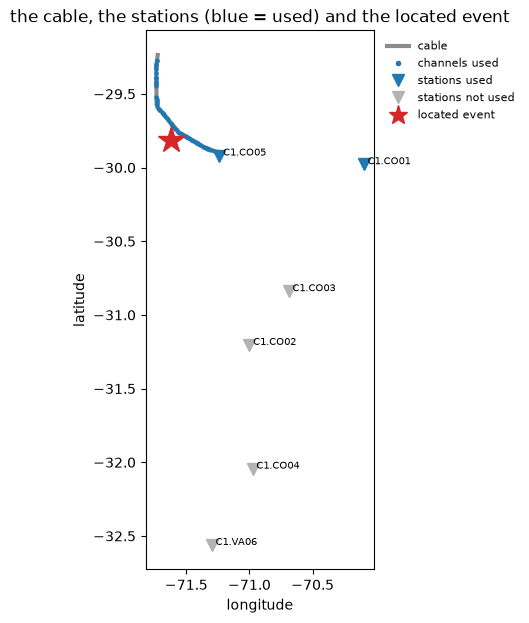

In [12]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

used = set(combined_picks.loc[combined_picks["assoc"], "id"])

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(
    cable["longitude"].values, cable["latitude"].values,
    "-", lw=3, c="0.55", zorder=1,
)
contributing = das_stations[das_stations["id"].isin(used)]
ax.plot(contributing["longitude"], contributing["latitude"], ".", ms=4, c="C0", zorder=2)

for _, station in stations.iterrows():
    ax.plot(
        station["longitude"],
        station["latitude"],
        "v",
        ms=9,
        c="C0" if station["id"] in used else "0.7",
        zorder=3,
    )
    ax.text(station["longitude"] + 0.03, station["latitude"], station["id"], fontsize=7)

ax.plot(event["longitude"], event["latitude"], "*", ms=20, c="C3", zorder=4)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("the cable, the stations (blue = used) and the located event")
ax.set_aspect(1 / np.cos(np.deg2rad(31)))
ax.legend(
    handles=[
        Line2D([], [], color="0.55", lw=3, label="cable"),
        Line2D([], [], marker=".", ls="none", ms=6, color="C0", label="channels used"),
        Line2D([], [], marker="v", ls="none", ms=8, color="C0", label="stations used"),
        Line2D([], [], marker="v", ls="none", ms=8, color="0.7", label="stations not used"),
        Line2D([], [], marker="*", ls="none", ms=14, color="C3", label="located event"),
    ],
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=8,
)
plt.show()

## Checking it arrival by arrival

A location is a hypothesis. The honest test is to predict every network
arrival from it and look at the residuals — the land picks are the ones the
fibre had no say in, so they are where the fit can be caught out:

In [13]:
from obspy.geodetics import gps2dist_azimuth

velocity = {"P": config["vel"]["p"], "S": config["vel"]["s"]}
coords = combined_stations.set_index("id")

check = gamma_picks.copy()
check["phase"] = check["type"].str.upper()
distances = []
for _, row in check.iterrows():
    station = coords.loc[row["id"]]
    metres, _, _ = gps2dist_azimuth(
        event["latitude"], event["longitude"], station["latitude"], station["longitude"]
    )
    distances.append(np.hypot(metres / 1000.0, event["depth(km)"]))
check["hypo(km)"] = distances
check["predicted"] = [
    origin + pd.Timedelta(seconds=d / velocity[p])
    for d, p in zip(check["hypo(km)"], check["phase"])
]
check["residual(s)"] = (check["timestamp"] - check["predicted"]).dt.total_seconds()
# the land picks are the first rows of the combined table, in order
check["used"] = combined_picks["assoc"].iloc[: len(check)].to_numpy()
check.sort_values("hypo(km)")[["id", "phase", "hypo(km)", "residual(s)", "used"]]

,id,phase,hypo(km),residual(s),used
9,C1.CO05,S,47.800102,-0.870696,True
8,C1.CO05,P,47.800102,-0.495684,True
5,C1.CO03,S,147.277717,-5.065001,False
4,C1.CO03,P,147.277717,-2.795286,False
0,C1.CO01,P,151.091024,-1.030837,True
1,C1.CO01,S,151.091024,-3.197215,False
3,C1.CO02,S,167.449671,-5.328487,False
2,C1.CO02,P,167.449671,-3.357278,False
7,C1.CO04,S,256.205136,-11.125500,False
6,C1.CO04,P,256.205136,-5.519858,False


`CO05` sits 48 km away, the closest thing the network has to a local
station, and its two picks land within a second — those, plus `CO01`'s P,
are what the associator kept. Everything beyond arrives *early*, and more so
with distance: a couple of seconds at 150 km, five at 250 km. That is the
velocity model, not the location. A single 6 km/s P is a crustal velocity;
at those distances the first arrival is Pn, refracted along the Moho at
nearly 8 km/s, so a constant-velocity prediction is always late.

The two `VA06` picks are off by tens of seconds. At 307 km that station
recorded nothing and the picker labelled noise. GaMMA left them out, which is
exactly what an associator is for.

So the hypocentre here is a fibre solution: a hundred-odd picks spread over
100 km of cable almost directly above the source outvote six distant
stations, and rightly so — they are the only ones whose travel times the
velocity model can actually reproduce.

## A second opinion from the fibre

The S−P interval at a channel is a hypocentral distance on its own. It uses
no location and no origin time, just the gap between two arrivals at one
point — so comparing it with the distance implied by the hypocentre is a
check that does not go through the fit:

In [14]:
first_p = das[das["phase"] == "P"].groupby("distance")["time"].min()
first_s = das[das["phase"] == "S"].groupby("distance")["time"].min()
both = first_p.index.intersection(first_s.index)
sp = (first_s[both] - first_p[both]).dt.total_seconds()

# the median, because a few channels have spurious picks
slowness = 1 / velocity["S"] - 1 / velocity["P"]

# the same distance, but read off the hypocentre instead of the arrival times
geometry = coords.reindex([f"DAS.{d:.0f}" for d in both])
offset = np.hypot(geometry["x(km)"] - event["x(km)"], geometry["y(km)"] - event["y(km)"])
predicted = np.hypot(offset, event["depth(km)"])

print(f"channels with both phases : {len(both)}")
print(f"median S-P                : {sp.median():.2f} s")
print(f"range implied by S-P      : {sp.median() / slowness:.0f} km")
print(f"range from the hypocentre : {predicted.median():.0f} km")
print(f"  event depth             : {event['depth(km)']:.0f} km")
print(f"  horizontal offset       : {offset.median():.0f} km")

channels with both phases : 169
median S-P                : 4.54 s
range implied by S-P      : 36 km
range from the hypocentre : 37 km
  event depth             : 28 km
  horizontal offset       : 24 km


Thirty-six kilometres from a pair of arrival times, thirty-seven from the
hypocentre and the cable geometry. The event sits about 24 km to the side of
the median channel and 28 km down, so this is not the depth read twice: it
is the same triangle closed two different ways, and a measurement that used
no location at all lands within a kilometre of the associated one.

## One figure

Time against position for every pick: the DAS channels by their distance
along the cable, the six land stations on a lane each below it. A pick is
coloured by phase where GaMMA associated it, faint where the random
subsample never offered it, and grey where it was offered and rejected —
which is the per-channel noise and the far stations the residual table
already flagged. The lines are the arrivals predicted from the located
hypocentre on the same two constant velocities, drawn as a moveout curve
along the cable and as a tick on each land lane.

The faint picks are the point of the subsample: the two thirds GaMMA never
saw fall on the same moveout as the third it did.

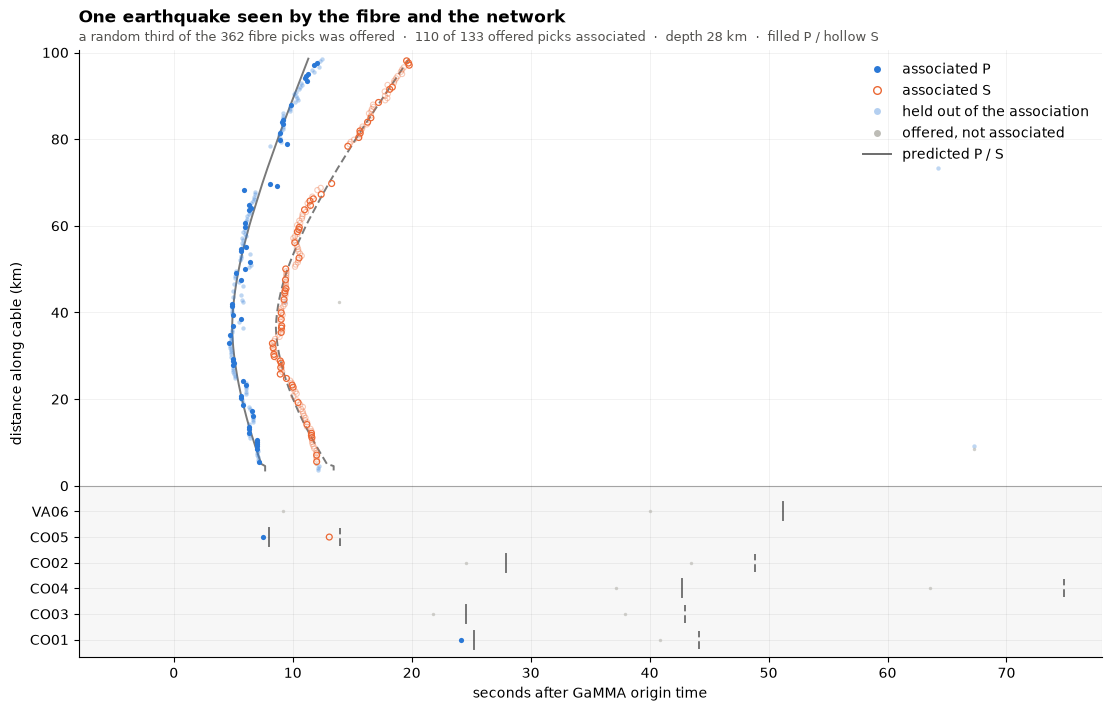

In [15]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# every pick, associated or not, offered to the association or held back
p = pd.concat(
    [
        combined_picks.assign(offered=True),
        held_out.assign(offered=False, assoc=False),
    ],
    ignore_index=True,
)
p["dt"] = (p["timestamp"] - origin).dt.total_seconds()
p["is_p"] = p["type"].str.upper().eq("P")

# --- a y position for every pick: km along the cable, or a lane per station -
geom = combined_stations.set_index("id")
is_das = geom.index.str.startswith("DAS.")
cable_km = pd.Series(
    geom.index[is_das].str.split(".").str[1].astype(float).to_numpy() / 1e3,
    index=geom.index[is_das],
)
land = geom[~is_das].sort_values("longitude")  # west to east
step = 0.06 * cable_km.max()
lane = {sid: -step * (k + 1) for k, sid in enumerate(land.index)}
p["y"] = p["id"].map(lambda s: lane.get(s, cable_km.get(s, np.nan)))

# --- arrivals predicted from the located hypocentre -----------------------
ex, ey, ez = event["x(km)"], event["y(km)"], event["depth(km)"]
hypo = np.sqrt(
    (geom["x(km)"] - ex) ** 2 + (geom["y(km)"] - ey) ** 2 + (geom["z(km)"] - ez) ** 2
)
tp, ts = hypo / config["vel"]["p"], hypo / config["vel"]["s"]
order = cable_km.sort_values().index

# --- draw ---------------------------------------------------------------
INK, GREY, P_C, S_C = "#0b0b0b", "#bdbcb6", "#2a78d6", "#eb6834"
fig, ax = plt.subplots(figsize=(11, 7), layout="constrained")
ax.axhspan(min(lane.values()) - step, 0, color=INK, alpha=0.03, zorder=0)

ax.plot(tp[order], cable_km[order], color=INK, lw=1.4, alpha=0.55, zorder=2)
ax.plot(ts[order], cable_km[order], color=INK, lw=1.4, alpha=0.55, ls=(0, (4, 2)), zorder=2)
for sid, y in lane.items():
    for t, dash in ((tp[sid], "-"), (ts[sid], (0, (4, 2)))):
        ax.plot([t, t], [y - 0.35 * step, y + 0.35 * step], color=INK, lw=1.4, alpha=0.55, ls=dash)

held = p[~p["offered"]]
ax.scatter(
    held.loc[held["is_p"], "dt"], held.loc[held["is_p"], "y"],
    s=10, c=P_C, lw=0, alpha=0.3, zorder=3,
)
ax.scatter(
    held.loc[~held["is_p"], "dt"], held.loc[~held["is_p"], "y"],
    s=14, facecolors="none", edgecolors=S_C, lw=0.8, alpha=0.35, zorder=3,
)

missed = p[p["offered"] & ~p["assoc"]]
ax.scatter(missed["dt"], missed["y"], s=6, c=GREY, lw=0, alpha=0.7, zorder=4)

hit = p[p["assoc"]]
ax.scatter(hit.loc[hit["is_p"], "dt"], hit.loc[hit["is_p"], "y"], s=14, c=P_C, lw=0, zorder=5)
ax.scatter(
    hit.loc[~hit["is_p"], "dt"], hit.loc[~hit["is_p"], "y"],
    s=18, facecolors="none", edgecolors=S_C, lw=0.9, zorder=5,
)

ax.axhline(0, color=INK, lw=0.8, alpha=0.3)
pos = [t for t in ax.get_yticks() if t >= 0]
ax.set_yticks(pos + list(lane.values()))
ax.set_yticklabels([f"{t:g}" for t in pos] + [s.split(".")[-1] for s in lane])
ax.set_xlim(-8, 78)
ax.set_ylim(min(lane.values()) - 0.7 * step, cable_km.max() * 1.02)
ax.set_xlabel("seconds after GaMMA origin time")
ax.set_ylabel("distance along cable (km)")
ax.grid(True, color=INK, alpha=0.06, lw=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title(
    "One earthquake seen by the fibre and the network",
    loc="left", pad=20, fontweight="bold",
)
ax.text(
    0, 1.015,
    f"a random third of the {len(das_gamma_picks)} fibre picks was offered  ·  "
    f"{int(p['assoc'].sum())} of {len(combined_picks)} offered picks associated  ·  "
    f"depth {event['depth(km)']:.0f} km  ·  filled P / hollow S",
    transform=ax.transAxes, fontsize=9, color="#52514e",
)
ax.legend(
    handles=[
        Line2D([], [], marker="o", ls="none", ms=5, mfc=P_C, mec="none", label="associated P"),
        Line2D([], [], marker="o", ls="none", ms=5.5, mfc="none", mec=S_C, mew=1, label="associated S"),
        Line2D([], [], marker="o", ls="none", ms=5, mfc=P_C, mec="none", alpha=0.35, label="held out of the association"),
        Line2D([], [], marker="o", ls="none", ms=5, mfc=GREY, mec="none", label="offered, not associated"),
        Line2D([], [], color=INK, lw=1.4, alpha=0.6, label="predicted P / S"),
    ],
    loc="upper right", frameon=False,
)
plt.show()